# EXPLORATORY DATA ANALYSIS - USING PYTHON
By 
### Nwuzor Tony
_Data Scientist_
> > >  19/08/2025

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import warnings
warnings.filterwarnings('ignore')

## Impomrting DataSet & Analysing the data 

In [3]:
sales_data = pd.read_csv("sales_data.csv")

In [4]:
sales_data.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [5]:
sales_data.tail()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
995,1010,2023-04-15,Charlie,North,4733.88,4,Food,4943.03,5442.15,Returning,0.29,Cash,Online,North-Charlie
996,1067,2023-09-07,Bob,North,4716.36,37,Clothing,1754.32,1856.40,New,0.21,Bank Transfer,Retail,North-Bob
997,1018,2023-04-27,David,South,7629.70,17,Clothing,355.72,438.27,Returning,0.06,Bank Transfer,Online,South-David
998,1100,2023-12-20,David,West,1629.47,39,Electronics,3685.03,3743.39,New,0.01,Bank Transfer,Online,West-David
999,1086,2023-08-16,Alice,East,4923.93,48,Food,2632.58,2926.68,Returning,0.14,Cash,Online,East-Alice


In [6]:
sales_data.shape

(1000, 14)

In [7]:
sales_data.describe()

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,5019.265230,25.355000,2475.304550,2728.440120,0.15239
std,29.573505,2846.790126,14.159006,1417.872546,1419.399839,0.08720
min,1001.000000,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,9989.040000,49.000000,4995.300000,5442.150000,0.30000


In [8]:
sales_data.isna().sum()

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

In [9]:
sales_data.isnull().sum()

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

In [10]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB


In [11]:
sales_data.columns

Index(['Product_ID', 'Sale_Date', 'Sales_Rep', 'Region', 'Sales_Amount',
       'Quantity_Sold', 'Product_Category', 'Unit_Cost', 'Unit_Price',
       'Customer_Type', 'Discount', 'Payment_Method', 'Sales_Channel',
       'Region_and_Sales_Rep'],
      dtype='object')

In [12]:
sales_data.duplicated().sum()

0

In [13]:
sales_data.nunique()

Product_ID               100
Sale_Date                340
Sales_Rep                  5
Region                     4
Sales_Amount             998
Quantity_Sold             49
Product_Category           4
Unit_Cost                998
Unit_Price              1000
Customer_Type              2
Discount                  31
Payment_Method             3
Sales_Channel              2
Region_and_Sales_Rep      20
dtype: int64

In [14]:
df = sales_data

In [15]:
print(df.dtypes)

Product_ID                int64
Sale_Date                object
Sales_Rep                object
Region                   object
Sales_Amount            float64
Quantity_Sold             int64
Product_Category         object
Unit_Cost               float64
Unit_Price              float64
Customer_Type            object
Discount                float64
Payment_Method           object
Sales_Channel            object
Region_and_Sales_Rep     object
dtype: object


In [16]:
num_df = df.select_dtypes(include=[np.number])

In [17]:
num_df

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
0,1052,5053.97,18,152.75,267.22,0.09
1,1093,4384.02,17,3816.39,4209.44,0.11
2,1015,4631.23,30,261.56,371.40,0.20
3,1072,2167.94,39,4330.03,4467.75,0.02
4,1061,3750.20,13,637.37,692.71,0.08
...,...,...,...,...,...,...
995,1010,4733.88,4,4943.03,5442.15,0.29
996,1067,4716.36,37,1754.32,1856.40,0.21
997,1018,7629.70,17,355.72,438.27,0.06
998,1100,1629.47,39,3685.03,3743.39,0.01


In [18]:
corr_matrix = num_df.corr()

In [19]:
corr_matrix

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
Product_ID,1.000000,0.010221,0.094479,0.013402,0.015116,-0.022097
Sales_Amount,0.010221,1.000000,-0.041599,0.009770,0.011812,0.023153
Quantity_Sold,0.094479,-0.041599,1.000000,0.053888,0.057296,-0.007806
Unit_Cost,0.013402,0.009770,0.053888,1.000000,0.995056,-0.017741
Unit_Price,0.015116,0.011812,0.057296,0.995056,1.000000,-0.017027
Discount,-0.022097,0.023153,-0.007806,-0.017741,-0.017027,1.000000


## Setting up X and Y Co-ordinates

In [77]:
X = sales_data.drop(columns='Sales_Amount', axis=1)
Y = sales_data['Sales_Amount']

## Data Visualization

### Visualizing column 'Quantity_Sold'

In [79]:
X = sales_data.drop(columns='Quantity_Sold', axis=1)
Y = sales_data['Quantity_Sold']

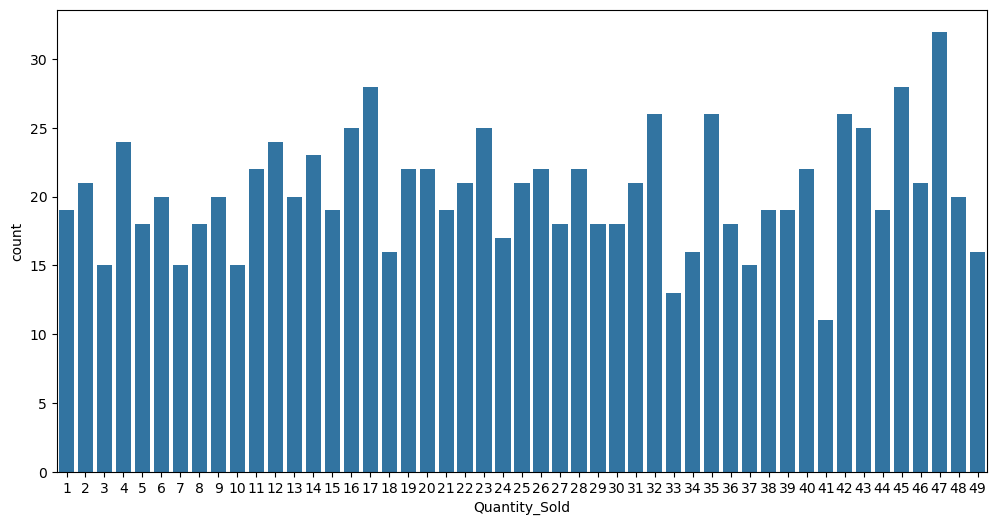

In [80]:
plt.figure(figsize = (12, 6))
sns.countplot(x = 'Quantity_Sold', data = sales_data)
plt.show()

In [77]:
X = sales_data.drop(columns='Sales_Amount', axis=1)
Y = sales_data['Sales_Amount']

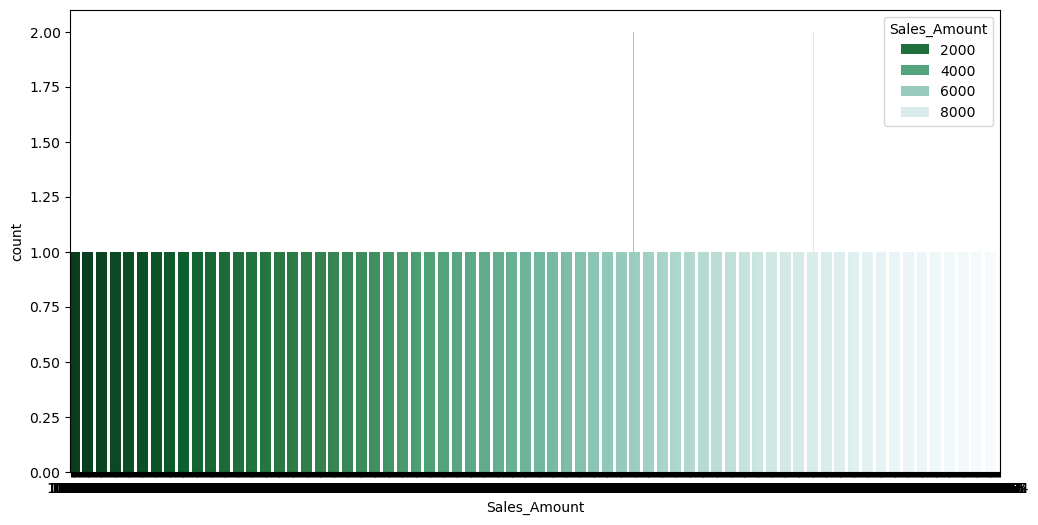

In [87]:
plt.figure(figsize = (12, 6))
sns.countplot(x = 'Sales_Amount', hue="Sales_Amount", data = sales_data, 
         palette ="BuGn_r")
plt.show()

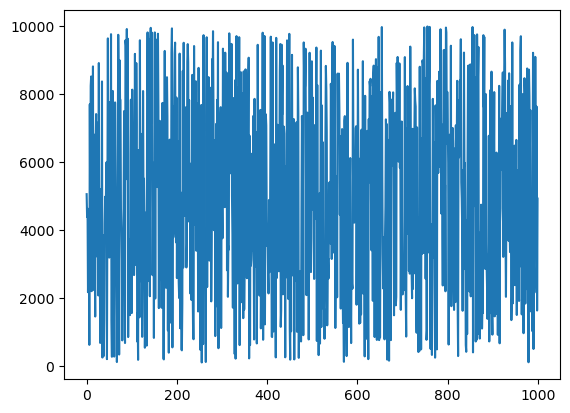

In [49]:
Sales_Amount = sales_data['Sales_Amount'].plot()
plt.show() 

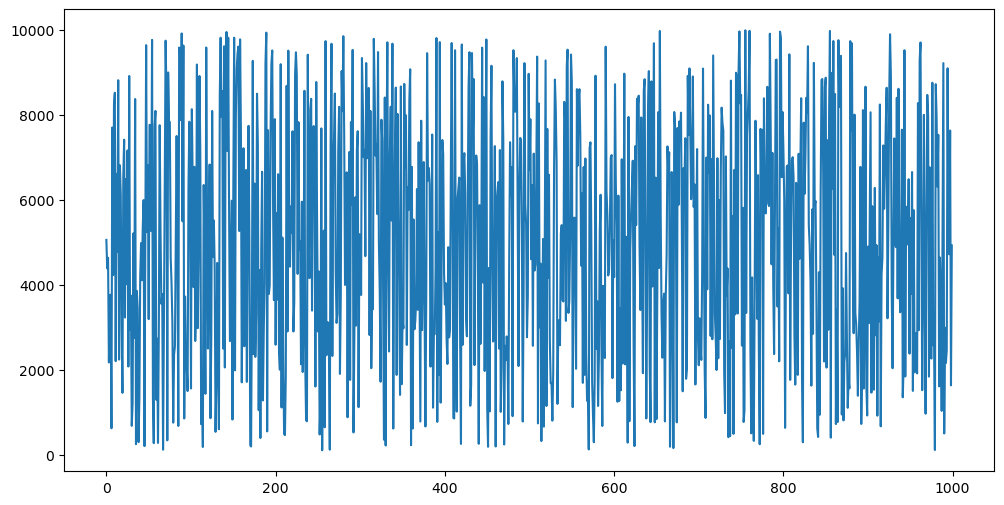

In [50]:
plt.figure(figsize = (12, 6)), Sales_Amount == sales_data['Sales_Amount'].plot()
plt.show() 

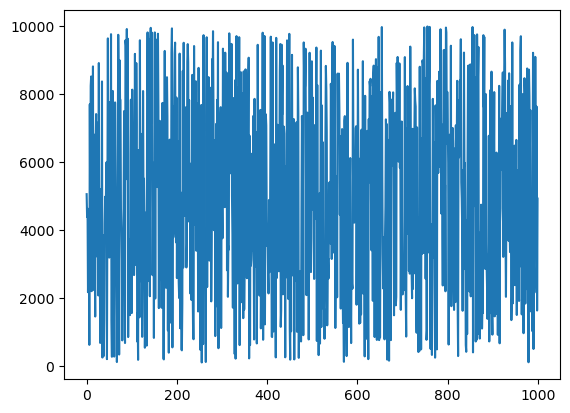

In [51]:
sales_data['Sales_Amount'].plot()
plt.show()

## Visualizing other columns

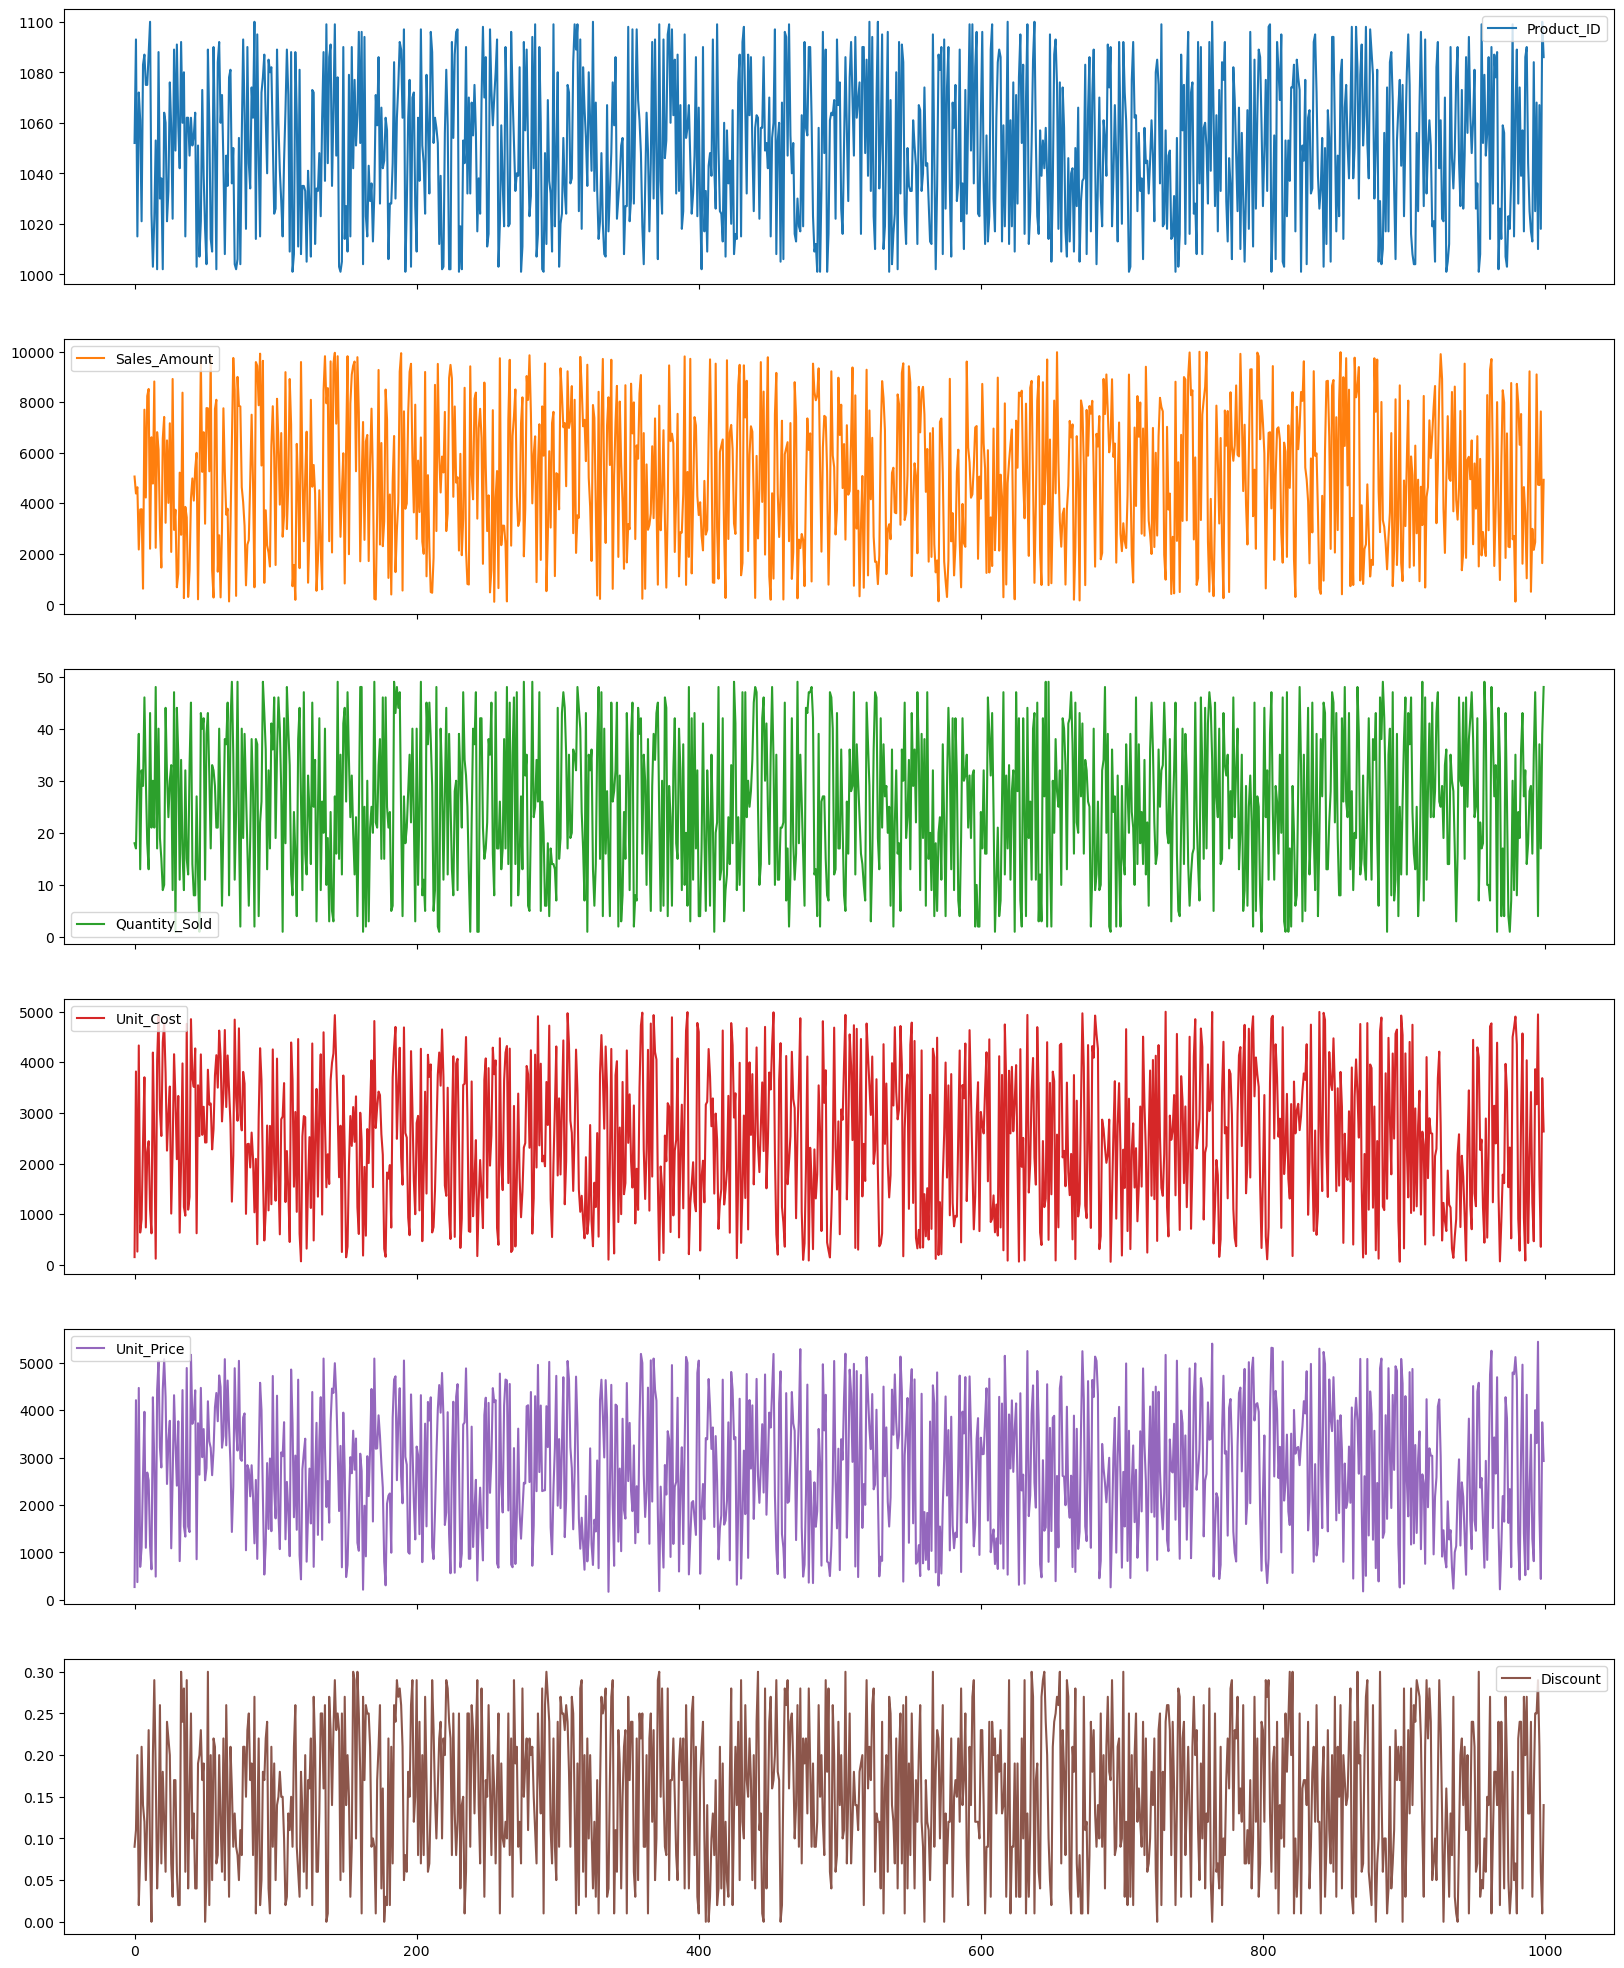

In [52]:
df.plot(subplots=True, figsize=(20,25));
plt.show()

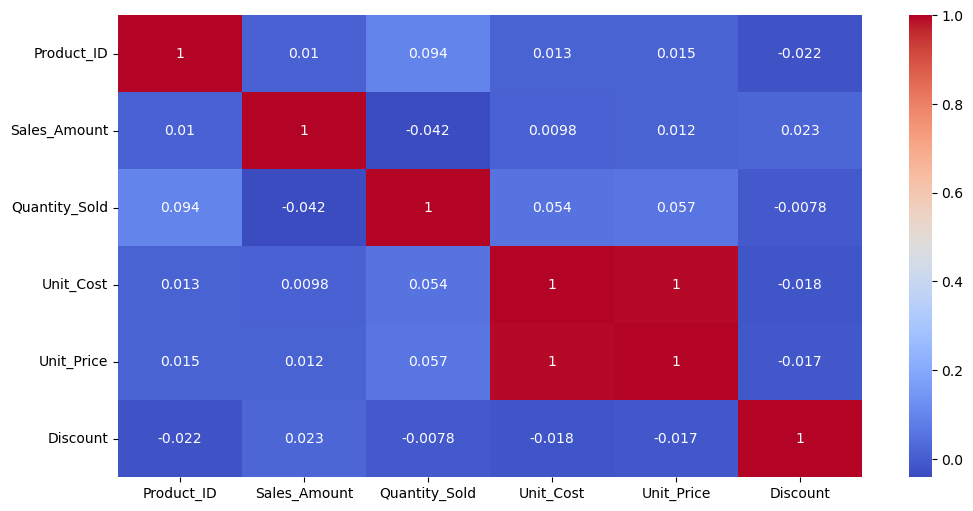

In [20]:
plt.figure(figsize=(12, 6))
df[["Product_ID", "Quantity_Sold"]].corr()
sns.heatmap(corr_matrix, annot=True,
cmap="coolwarm")
plt.show()

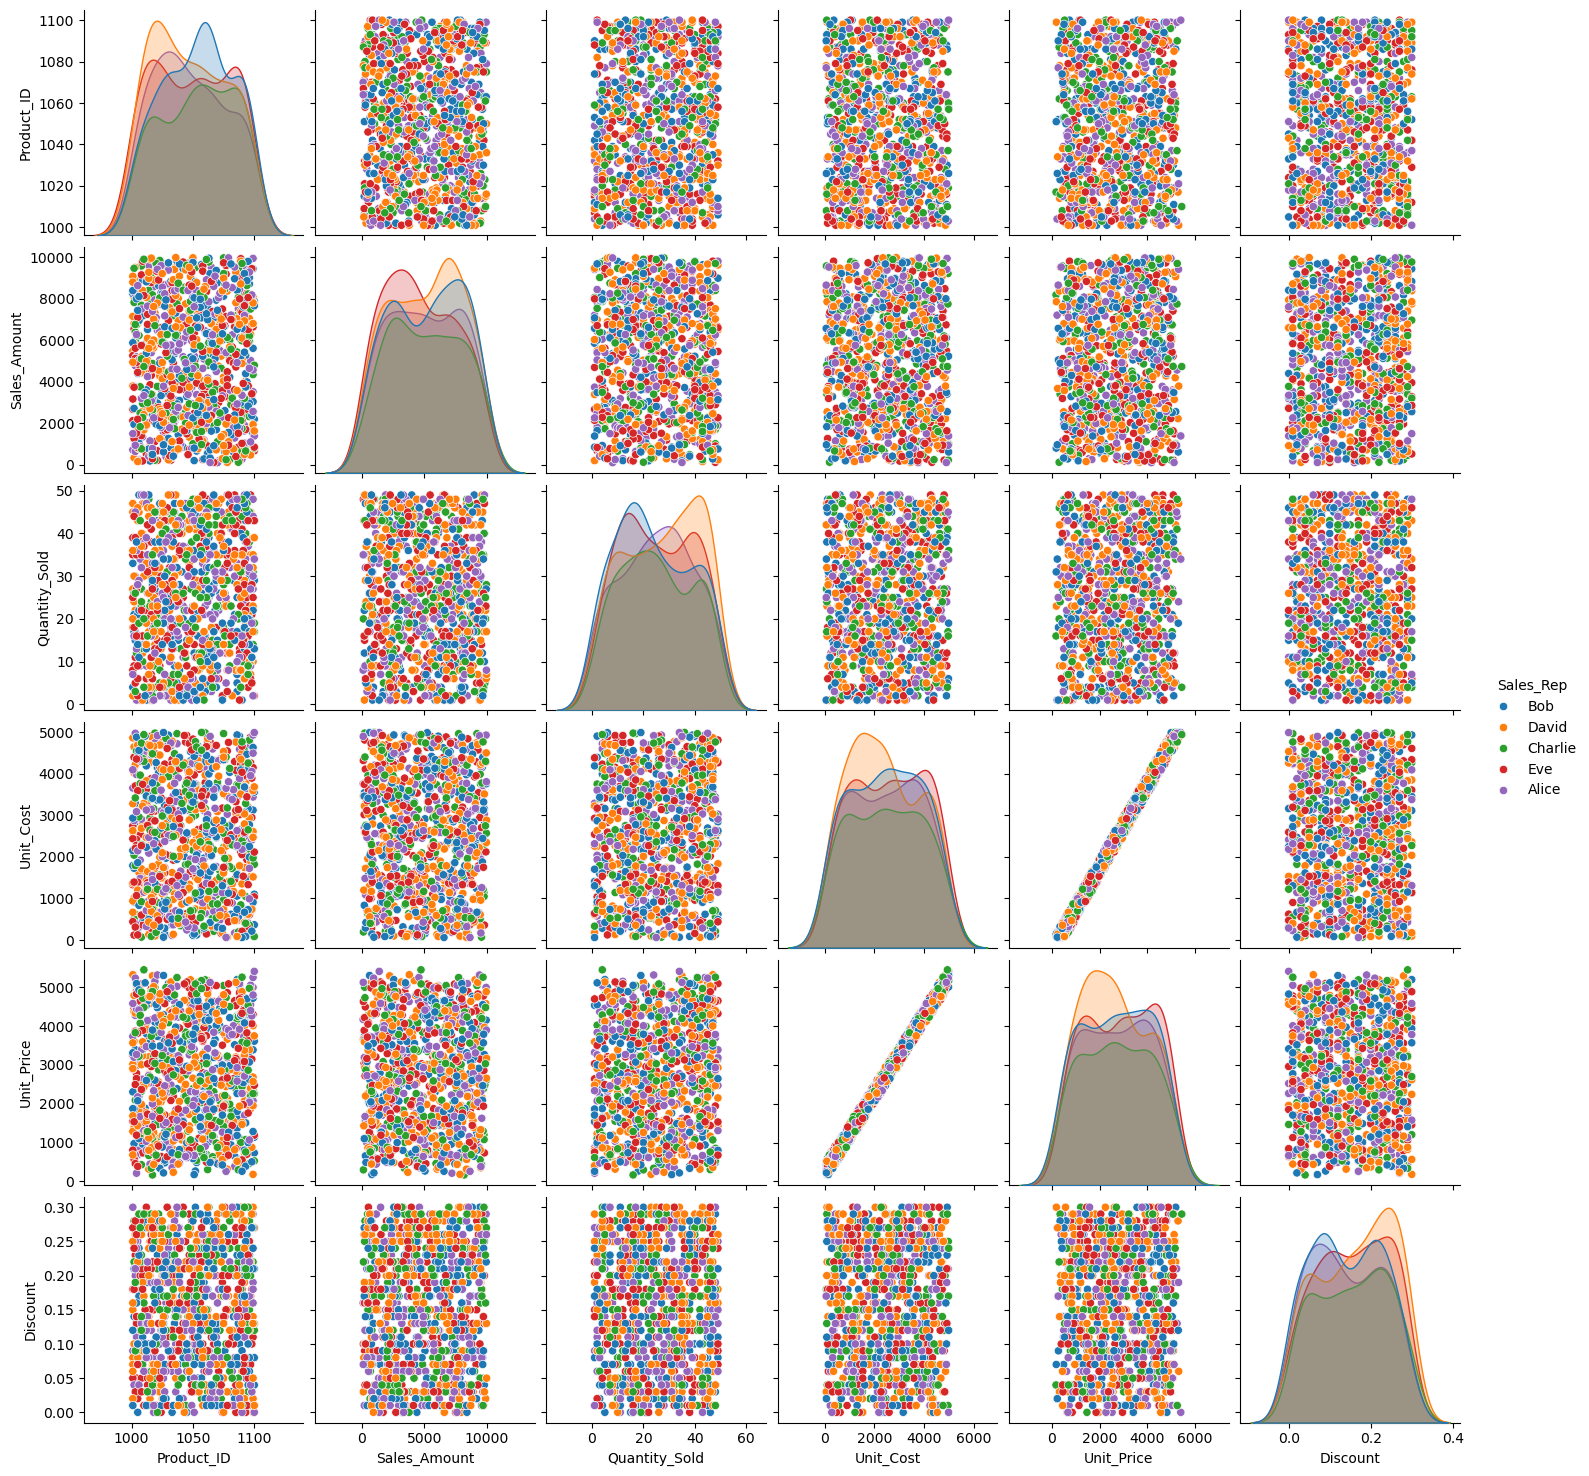

In [21]:
sns.pairplot(df, hue = 'Sales_Rep')
plt.show()

In [22]:
df['Payment_Method'].value_counts()

Payment_Method
Credit Card      345
Bank Transfer    342
Cash             313
Name: count, dtype: int64

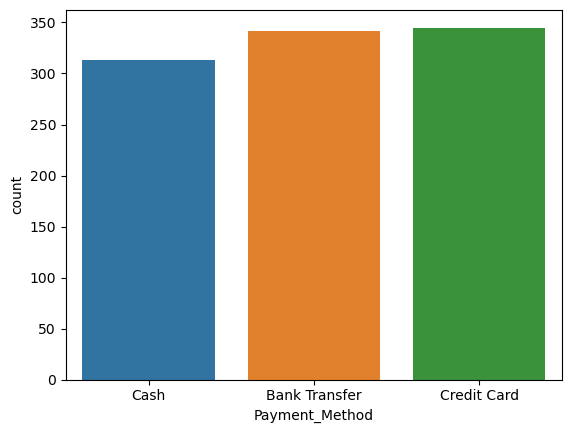

In [23]:
sns.countplot(x='Payment_Method', hue="Payment_Method", palette = 'tab10',
data = df, legend=False)
plt.show()

In [24]:
df['Region'].value_counts()

Region
North    267
East     263
West     244
South    226
Name: count, dtype: int64

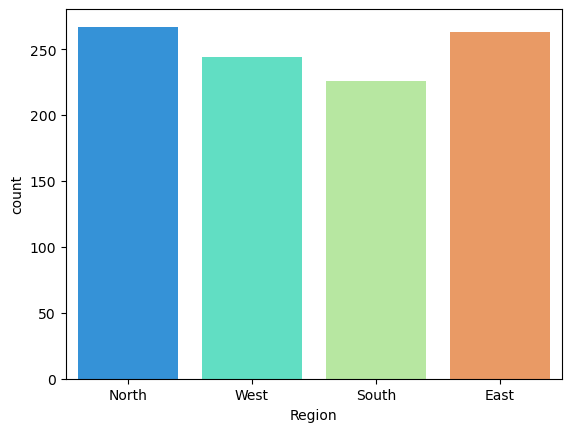

In [25]:
sns.countplot(x='Region', hue="Region", palette = 'rainbow',
data = df, legend=False)
plt.show()

In [26]:
df['Product_Category'].value_counts()

Product_Category
Clothing       268
Furniture      260
Electronics    246
Food           226
Name: count, dtype: int64

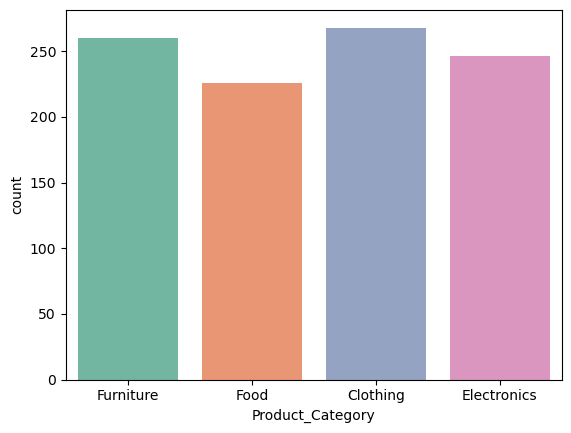

In [27]:
sns.countplot(x='Product_Category', hue="Product_Category", palette = 'Set2',
data = df, legend=False)
plt.show()

In [28]:
df['Customer_Type'].value_counts()

Customer_Type
New          504
Returning    496
Name: count, dtype: int64

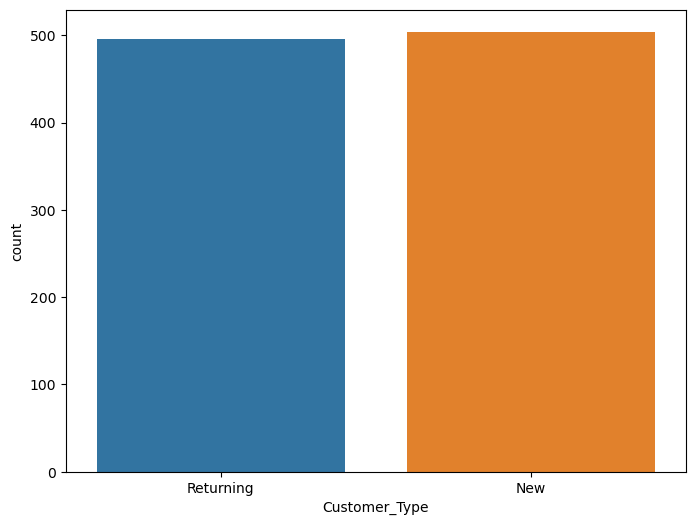

In [29]:
plt.figure(figsize = (8, 6)), sns.countplot(x='Customer_Type', hue="Customer_Type", palette = 'tab10',
data = df, legend=False)
plt.show()

In [30]:
df['Sales_Rep'].value_counts()

Sales_Rep
David      222
Eve        209
Bob        208
Alice      192
Charlie    169
Name: count, dtype: int64

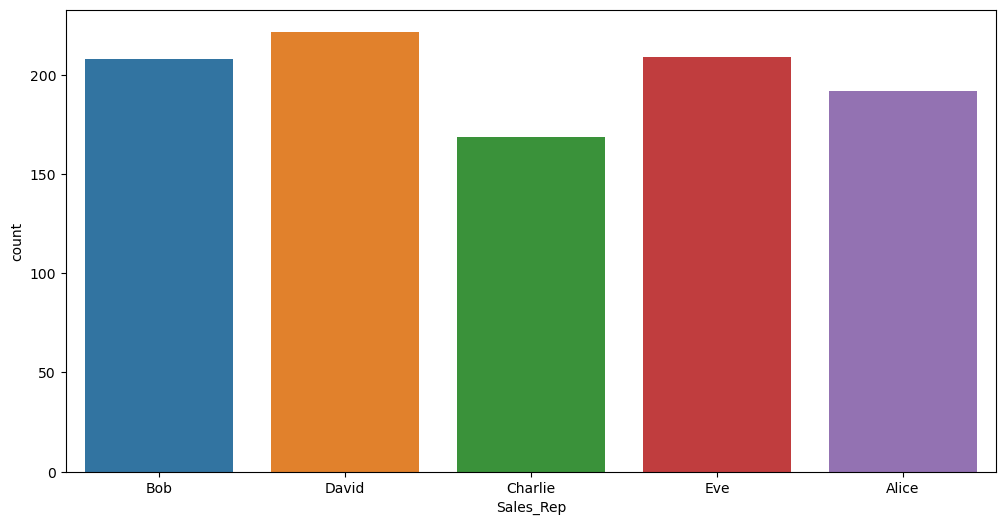

In [31]:
plt.figure(figsize = (12, 6)), sns.countplot(x='Sales_Rep', hue="Sales_Rep", palette = 'tab10',
data = df, legend=False)
plt.show()

## Observation 1

In [32]:
df['Region_and_Sales_Rep'].value_counts()

Region_and_Sales_Rep
North-Eve        64
East-Bob         60
East-David       59
South-David      56
North-David      56
North-Charlie    55
East-Eve         55
West-Bob         54
East-Alice       52
West-David       51
South-Bob        50
North-Alice      48
West-Alice       47
West-Eve         47
West-Charlie     45
South-Alice      45
North-Bob        44
South-Eve        43
East-Charlie     37
South-Charlie    32
Name: count, dtype: int64

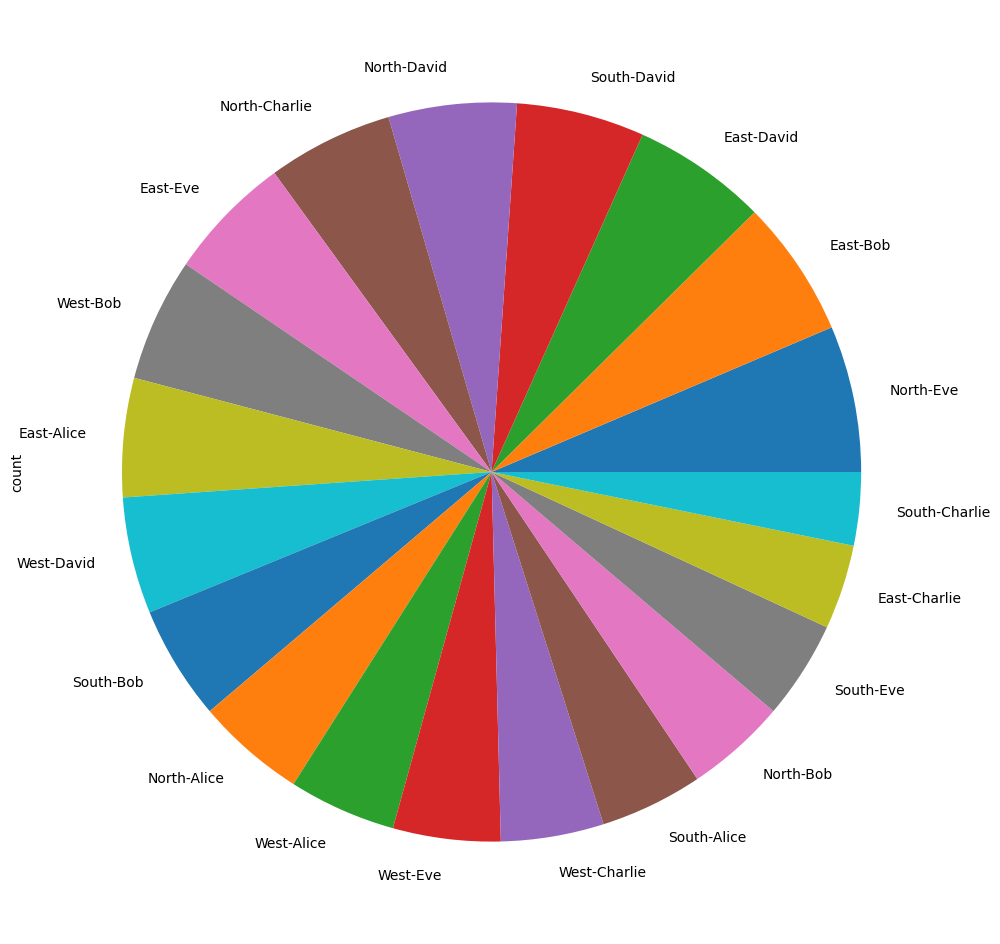

In [33]:
plt.figure(figsize=(15, 12))
df['Region_and_Sales_Rep'].value_counts().plot.pie()
plt.show()

## Observation 2

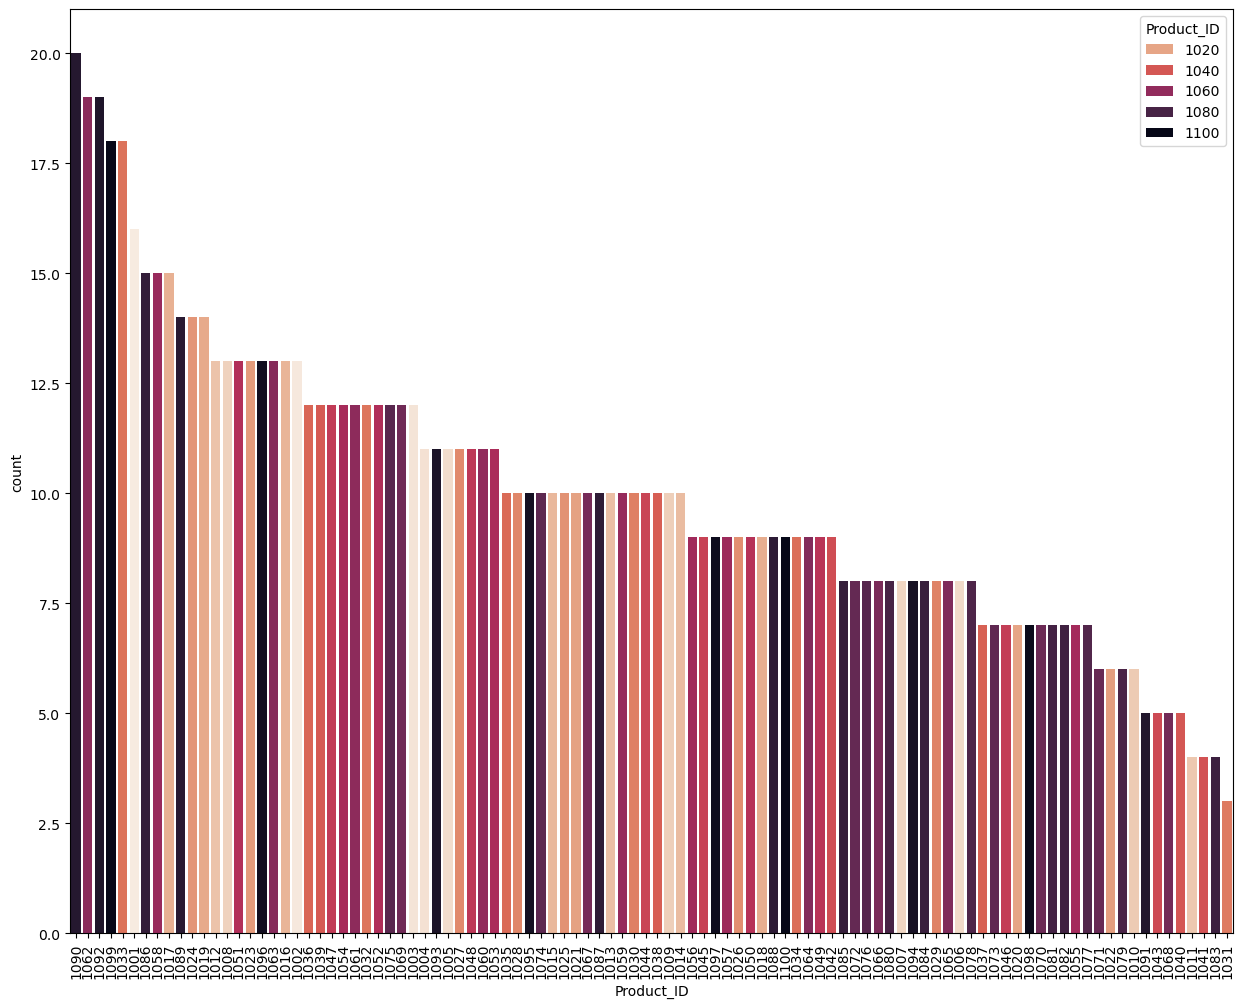

In [34]:
plt.figure(figsize=(15, 12))
sns.countplot(x='Product_ID', data=df, hue="Product_ID", palette = 'rocket_r', order=df['Product_ID'].value_counts().index)
plt.xticks(rotation=90)
plt.show()

##   Observation 3

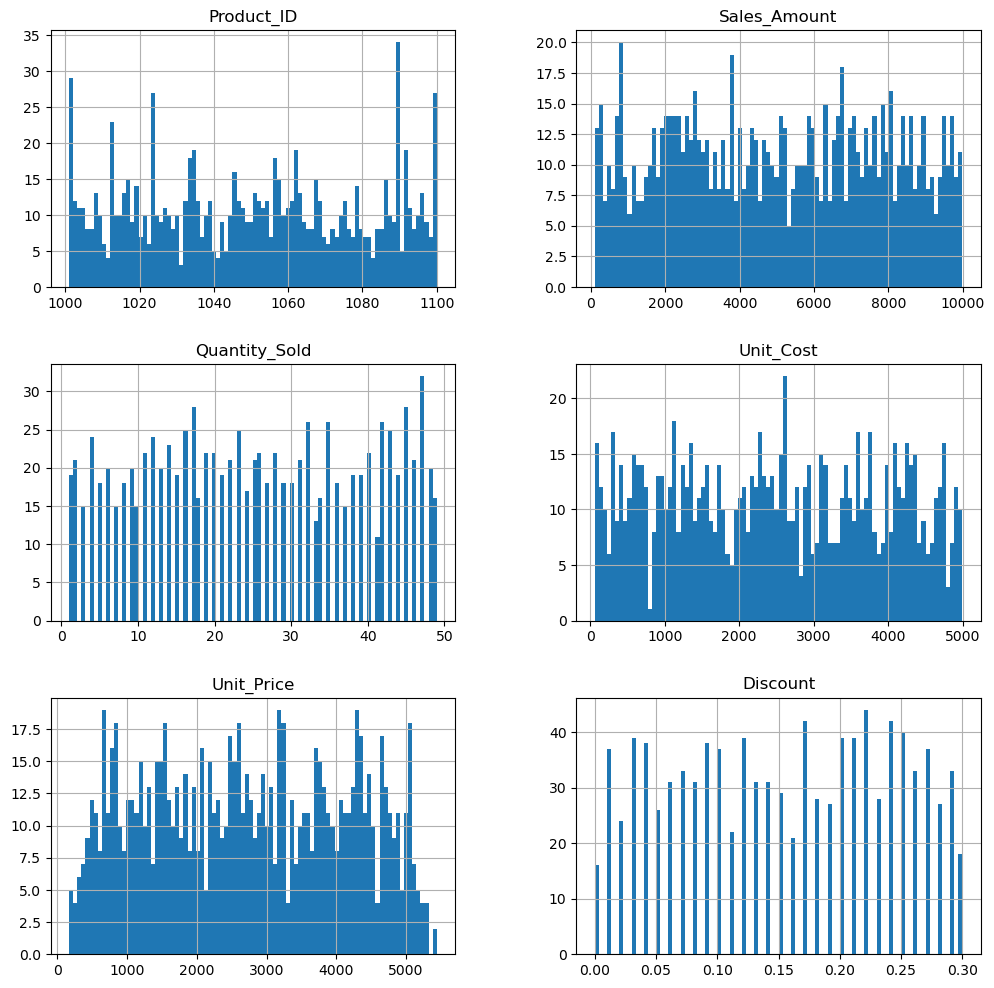

In [35]:
df.hist(figsize=(12, 12), bins=90)
plt.show()

## Observation 4

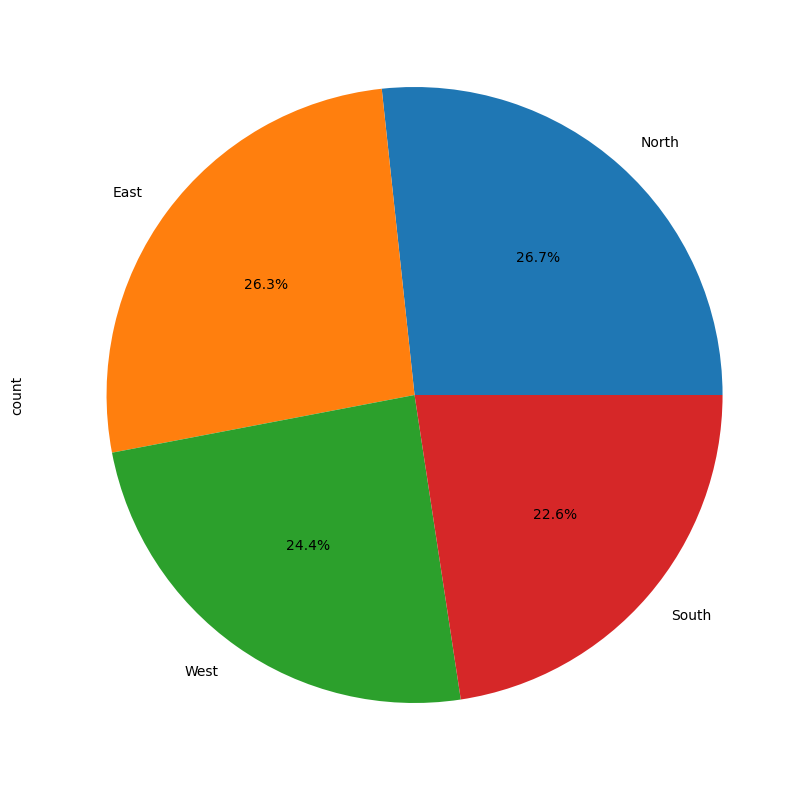

In [36]:
plt.figure(figsize=(12, 10))
df['Region'].value_counts().plot.pie(autopct = '%1.1f%%')
plt.show()

## Observation 5

### Quantity Sold vs Discount

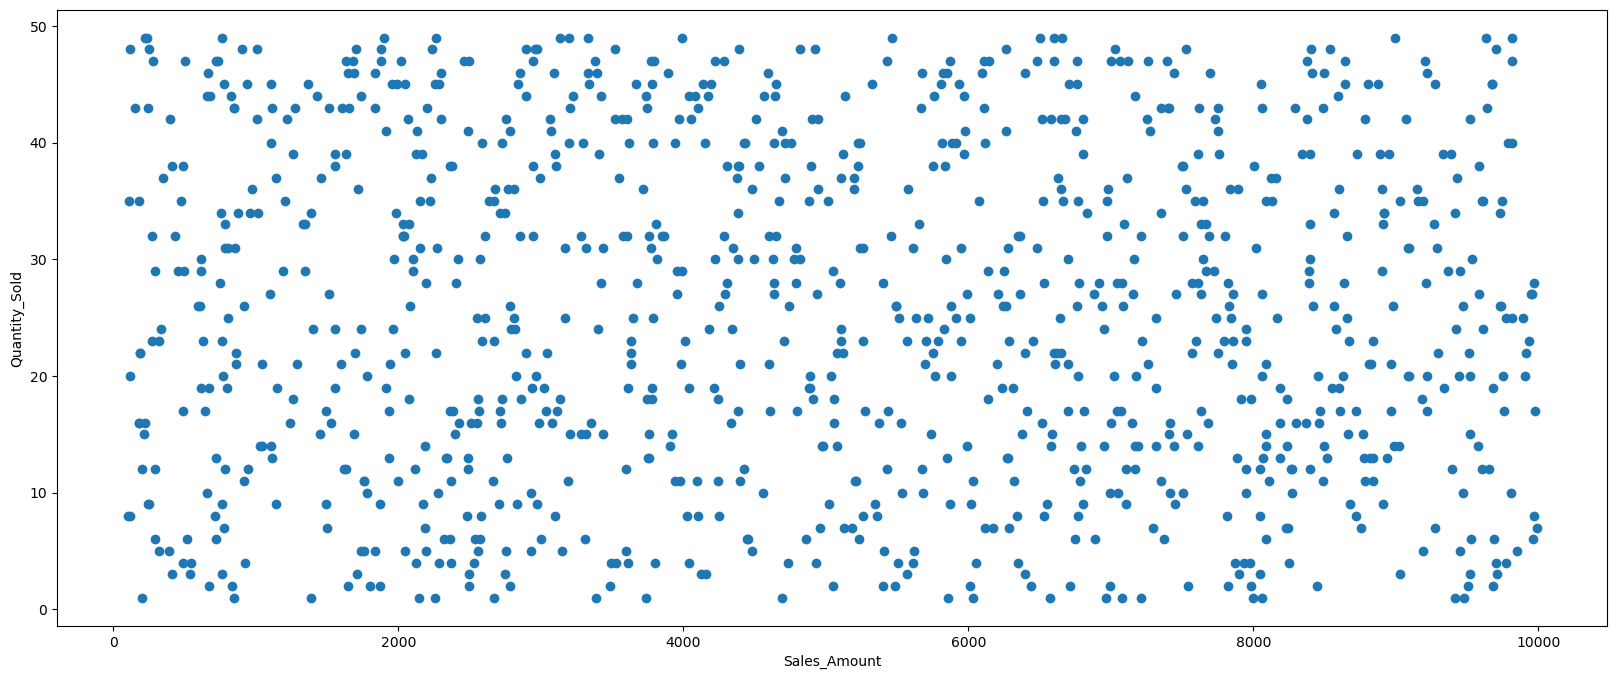

In [37]:
fig,ax=plt.subplots(figsize=(20, 8))
ax.scatter(df['Sales_Amount'], df['Quantity_Sold'])
ax.set_xlabel('Sales_Amount')
ax.set_ylabel('Quantity_Sold')
plt.show()

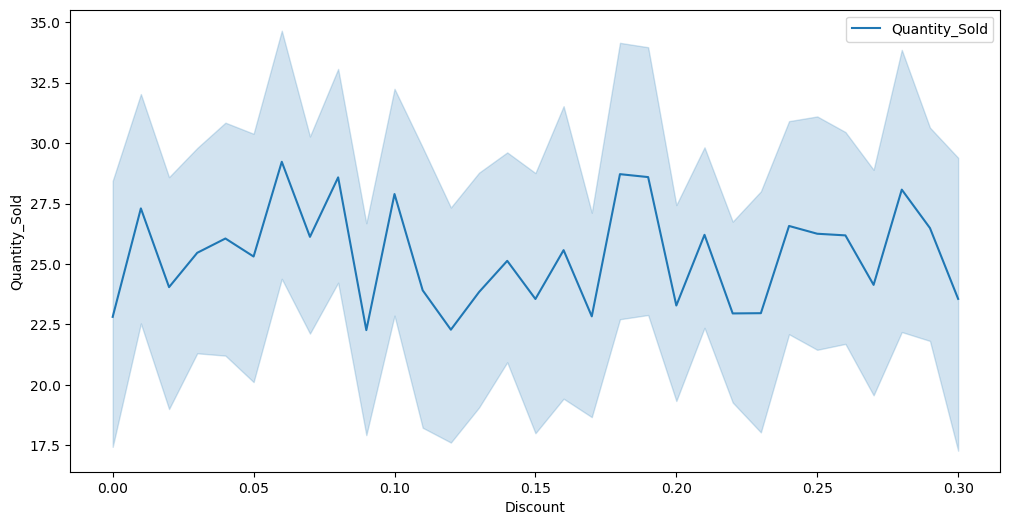

In [38]:
plt.figure(figsize = (12, 6))
sns.lineplot(x='Discount', y='Quantity_Sold', label='Quantity_Sold', data=df)
plt.legend()
plt.show()

## Observation 6

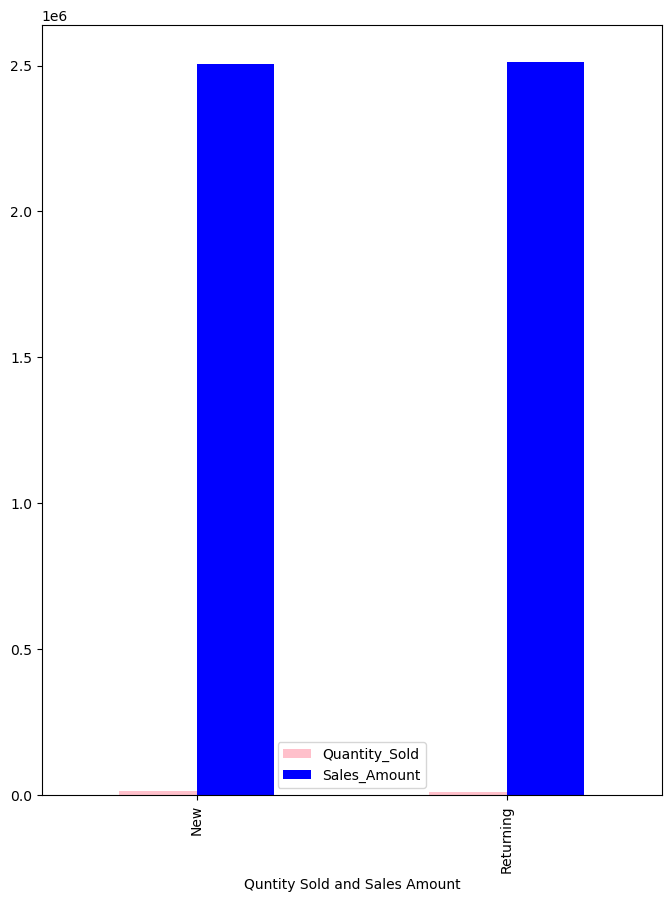

In [39]:
df.groupby('Customer_Type')[['Quantity_Sold', 'Sales_Amount']].sum().plot.bar(color=['pink', 'blue'], figsize=(8, 10))
plt.xlabel('Quntity Sold and Sales Amount')
plt.show()

In [40]:
df['Region'].value_counts().index

Index(['North', 'East', 'West', 'South'], dtype='object', name='Region')

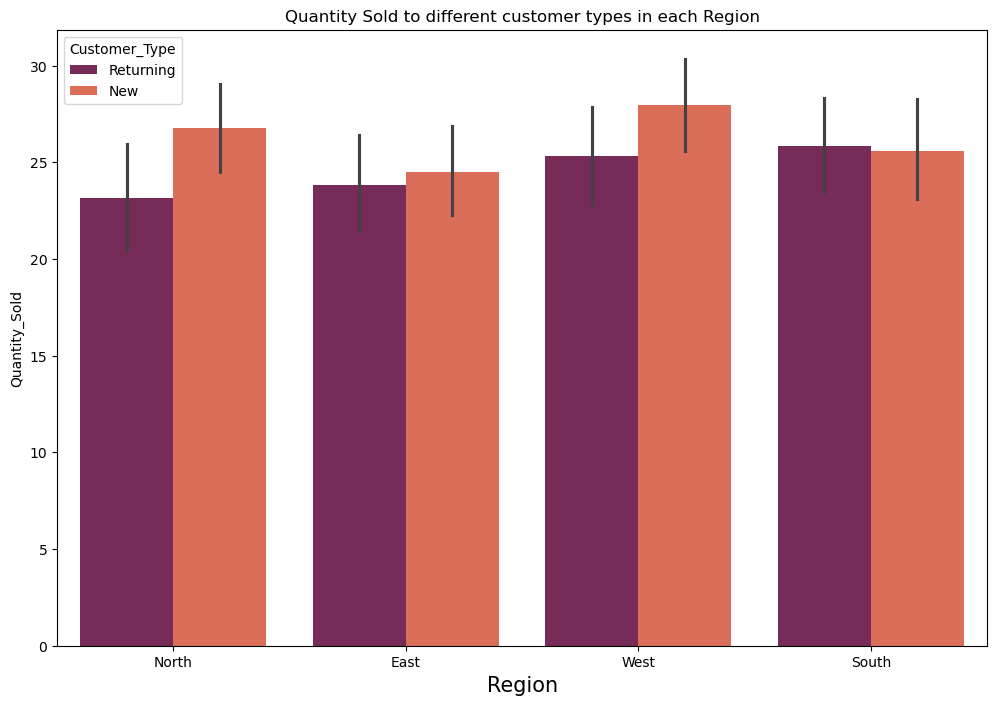

In [41]:
plt.figure(figsize=(12, 8))
plt.title('Quantity Sold to different customer types in each Region')
sns.barplot(x="Region", y="Quantity_Sold", data=df, hue="Customer_Type", order=df['Region'].value_counts().index, palette="rocket")
plt.xlabel("Region", fontsize=15)
plt.show()

## Observation 7

-  Sales made to the different customer types are almost the same in every region

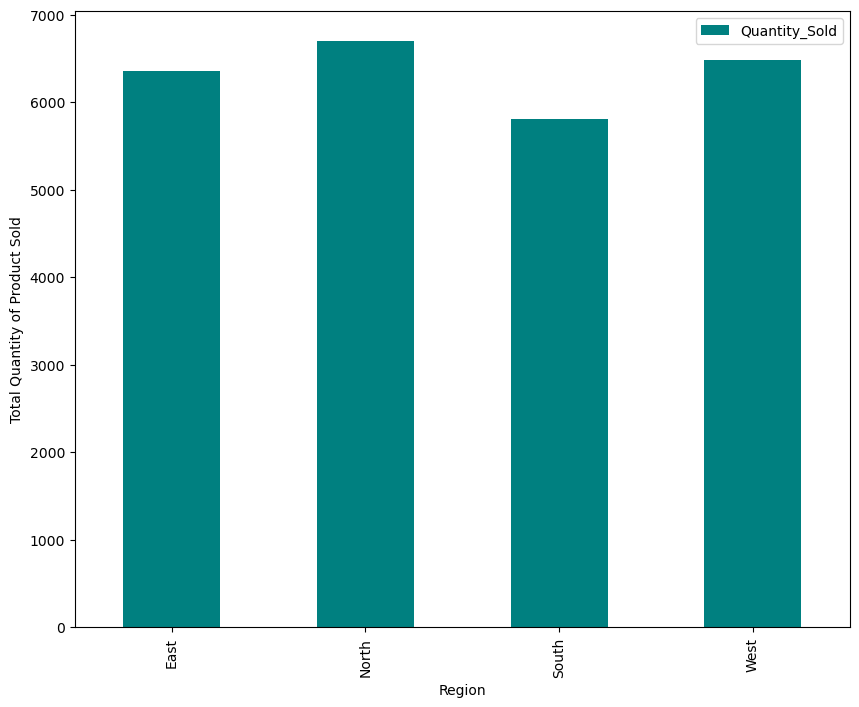

In [42]:
df.groupby('Region')[['Quantity_Sold', 'Product_Category']].sum().plot.bar(color=['teal', 'blue'], figsize=(10, 8))
plt.ylabel('Total Quantity of Product Sold')
plt.show()

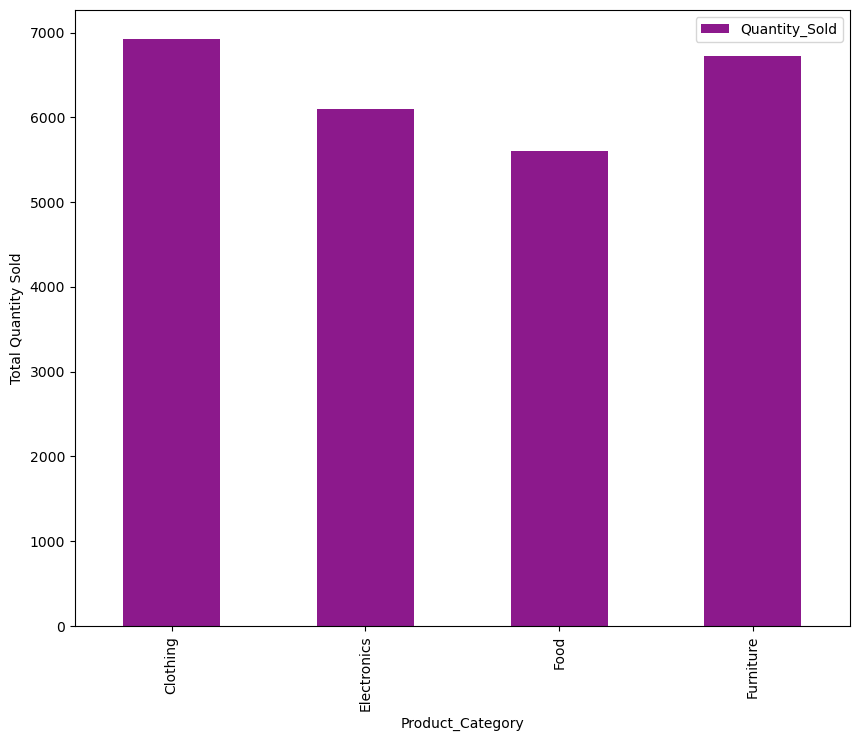

In [43]:
df.groupby('Product_Category')[['Quantity_Sold', 'Sales_Rep']].sum().plot.bar(color=['purple', 'red'], alpha=0.9, figsize=(10, 8))
plt.ylabel('Total Quantity Sold')
plt.show()

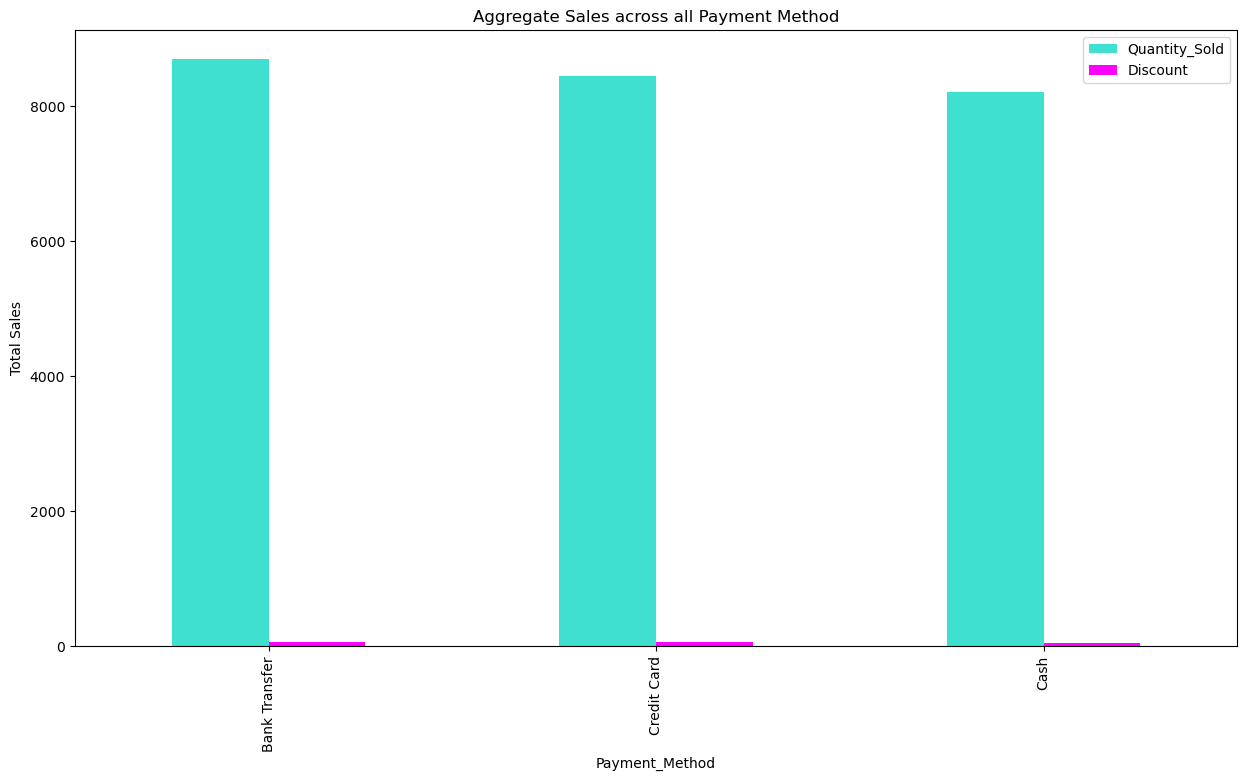

In [84]:
ps = df.groupby('Payment_Method')[['Quantity_Sold', 'Discount']].sum().sort_values(by='Quantity_Sold', ascending=False)
ps[:].plot.bar(color=['turquoise', 'magenta'], figsize=(15, 8))
plt.title('Aggregate Sales across all Payment Method')
plt.xlabel('Payment_Method')
plt.ylabel('Total Sales')
plt.show()